In [1]:
import pandas as pd
import json

import random
import geopandas as gpd
import numpy as np
import os

enc = 'utf-8'
random.seed(0)
np.random.seed(0)


c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
folder_path = 'shapefiles/EUROPE_NUTS_2021_4326'   

europe_nuts = gpd.read_file(f"{folder_path}/NUTS_RG_01M_2021_4326.shp",  encoding=enc)

In [3]:
country_codes = {'AT': 'Austria',
                'BE': 'Belgium',
                'BG': 'Bulgaria',
                'HR': 'Croatia',
                'CY': 'Cyprus',
                'CZ': 'Czech Republic',
                'DK': 'Denmark',
                'EE': 'Estonia',
                'FI': 'Finland',
                'FR': 'France',
                'DE': 'Germany',
                'EL': 'Greece',
                'HU': 'Hungary',
                'IS': 'Iceland',
                'IE': 'Ireland',
                'IT': 'Italy',
                'LV': 'Latvia',
                'LI': 'Liechtenstein',
                'LT': 'Lithuania',
                'LU': 'Luxembourg',
                'MT': 'Malta',
                'NL': 'Netherlands',
                'NO': 'Norway',
                'PL': 'Poland',
                'PT': 'Portugal',
                'RO': 'Romania',
                'SK': 'Slovakia',
                'SI': 'Slovenia',
                'ES': 'Spain',
                'SE': 'Sweden',
                'CH': 'Switzerland',
                'UK': 'United Kingdom',
                'AL': 'Albania',
                'ME': 'Montenegro',
                'MK': 'North Macedonia',
                'RS': 'Serbia',
                'TR': 'Turkey'}

In [5]:
with open("country_codes.json", "w", encoding=enc) as outfile:
    json.dump(country_codes, outfile, indent = 4)

In [6]:
europe_nuts

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
0,CZ,0,CZ,Česko,Česko,0.0,0,0,CZ,"POLYGON ((14.49122 51.04353, 14.49945 51.04610..."
1,DE,0,DE,Deutschland,Deutschland,0.0,0,0,DE,"MULTIPOLYGON (((10.45444 47.55580, 10.43954 47..."
2,DK,0,DK,Danmark,Danmark,0.0,0,0,DK,"MULTIPOLYGON (((15.19308 55.32014, 15.19056 55..."
3,AL,0,AL,Shqipëria,Shqipëria,0.0,0,0,AL,"MULTIPOLYGON (((19.83100 42.46645, 19.83568 42..."
4,CY,0,CY,Kýpros,Κύπρος,0.0,0,0,CY,"MULTIPOLYGON (((34.60609 35.70767, 34.60060 35..."
...,...,...,...,...,...,...,...,...,...,...
2005,UKM73,3,UK,East Lothian and Midlothian,East Lothian and Midlothian,4.0,1,1,UKM73,"MULTIPOLYGON (((-2.36662 55.94611, -2.36697 55..."
2006,UKM75,3,UK,"Edinburgh, City of","Edinburgh, City of",4.0,1,1,UKM75,"MULTIPOLYGON (((-3.07764 55.94689, -3.08167 55..."
2007,UKM76,3,UK,Falkirk,Falkirk,4.0,1,1,UKM76,"POLYGON ((-3.51572 56.00226, -3.51251 55.99411..."
2008,UKM78,3,UK,West Lothian,West Lothian,4.0,1,1,UKM78,"POLYGON ((-3.42533 55.99403, -3.42699 55.99050..."


In [7]:
europe_nuts['CNTR_NAME'] = europe_nuts['CNTR_CODE'].map(country_codes) 

In [8]:
europe_nuts

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry,CNTR_NAME
0,CZ,0,CZ,Česko,Česko,0.0,0,0,CZ,"POLYGON ((14.49122 51.04353, 14.49945 51.04610...",Czech Republic
1,DE,0,DE,Deutschland,Deutschland,0.0,0,0,DE,"MULTIPOLYGON (((10.45444 47.55580, 10.43954 47...",Germany
2,DK,0,DK,Danmark,Danmark,0.0,0,0,DK,"MULTIPOLYGON (((15.19308 55.32014, 15.19056 55...",Denmark
3,AL,0,AL,Shqipëria,Shqipëria,0.0,0,0,AL,"MULTIPOLYGON (((19.83100 42.46645, 19.83568 42...",Albania
4,CY,0,CY,Kýpros,Κύπρος,0.0,0,0,CY,"MULTIPOLYGON (((34.60609 35.70767, 34.60060 35...",Cyprus
...,...,...,...,...,...,...,...,...,...,...,...
2005,UKM73,3,UK,East Lothian and Midlothian,East Lothian and Midlothian,4.0,1,1,UKM73,"MULTIPOLYGON (((-2.36662 55.94611, -2.36697 55...",United Kingdom
2006,UKM75,3,UK,"Edinburgh, City of","Edinburgh, City of",4.0,1,1,UKM75,"MULTIPOLYGON (((-3.07764 55.94689, -3.08167 55...",United Kingdom
2007,UKM76,3,UK,Falkirk,Falkirk,4.0,1,1,UKM76,"POLYGON ((-3.51572 56.00226, -3.51251 55.99411...",United Kingdom
2008,UKM78,3,UK,West Lothian,West Lothian,4.0,1,1,UKM78,"POLYGON ((-3.42533 55.99403, -3.42699 55.99050...",United Kingdom


In [9]:
europe_nuts['NUTS_ID'].equals(europe_nuts['FID'])

True

In [10]:
europe_nuts.drop(columns=['FID'], inplace = True)

In [11]:
europe_nuts0 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 0].copy()
europe_nuts1 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 1].copy()
europe_nuts2 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 2].copy()
europe_nuts3 = europe_nuts.loc[europe_nuts['LEVL_CODE'] == 3].copy()

In [12]:
europe_nuts0.drop(columns=['LEVL_CODE', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE'], inplace = True)
europe_nuts1.drop(columns=['LEVL_CODE', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE'], inplace = True)
europe_nuts2.drop(columns=['LEVL_CODE', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE'], inplace = True)
europe_nuts3.drop(columns=['LEVL_CODE'], inplace = True)

europe_nuts0.reset_index(drop=True, inplace=True)
europe_nuts1.reset_index(drop=True, inplace=True)
europe_nuts2.reset_index(drop=True, inplace=True)
europe_nuts3.reset_index(drop=True, inplace=True)

In [13]:
print(f'europe_nuts0 CRS: {europe_nuts0.crs}')
print(f'europe_nuts1 CRS: {europe_nuts1.crs}')
print(f'europe_nuts2 CRS: {europe_nuts2.crs}')
print(f'europe_nuts3 CRS: {europe_nuts3.crs}')

europe_nuts0 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
europe_nuts1 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
europe_nuts2 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
europe_nuts3 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [14]:
europe_nuts0 = europe_nuts0.to_crs(epsg=4326)
europe_nuts1 = europe_nuts1.to_crs(epsg=4326)
europe_nuts2 = europe_nuts2.to_crs(epsg=4326)
europe_nuts3 = europe_nuts3.to_crs(epsg=4326)

In [15]:
print(f'europe_nuts0 CRS: {europe_nuts0.crs}')
print(f'europe_nuts1 CRS: {europe_nuts1.crs}')
print(f'europe_nuts2 CRS: {europe_nuts2.crs}')
print(f'europe_nuts3 CRS: {europe_nuts3.crs}')

europe_nuts0 CRS: epsg:4326
europe_nuts1 CRS: epsg:4326
europe_nuts2 CRS: epsg:4326
europe_nuts3 CRS: epsg:4326


<AxesSubplot:>

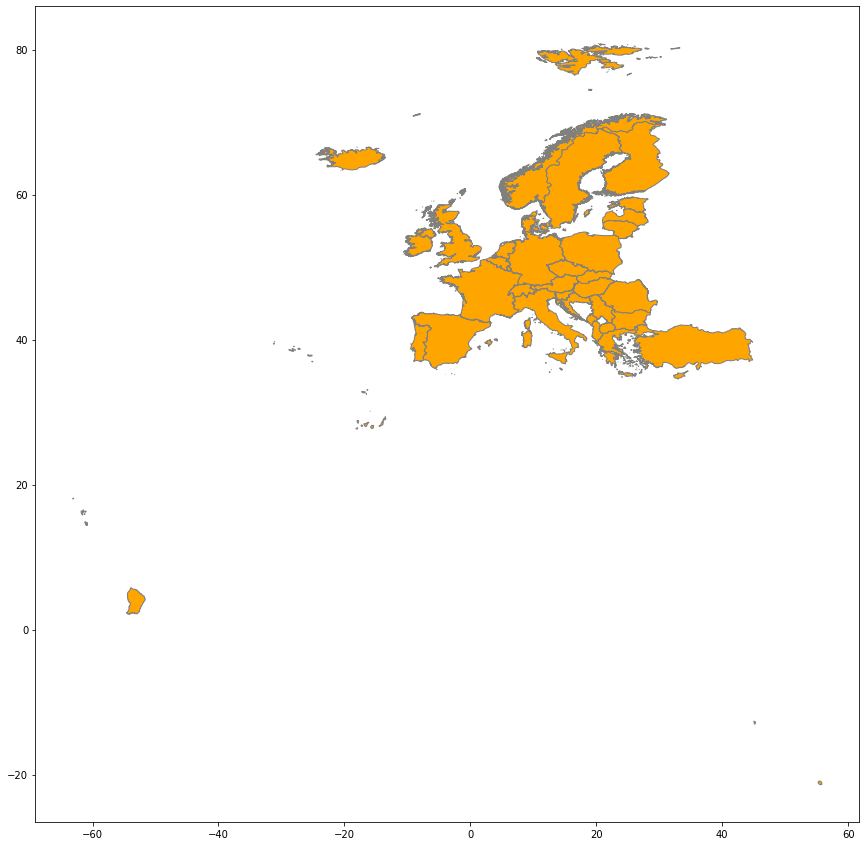

In [16]:
europe_nuts0.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

<AxesSubplot:>

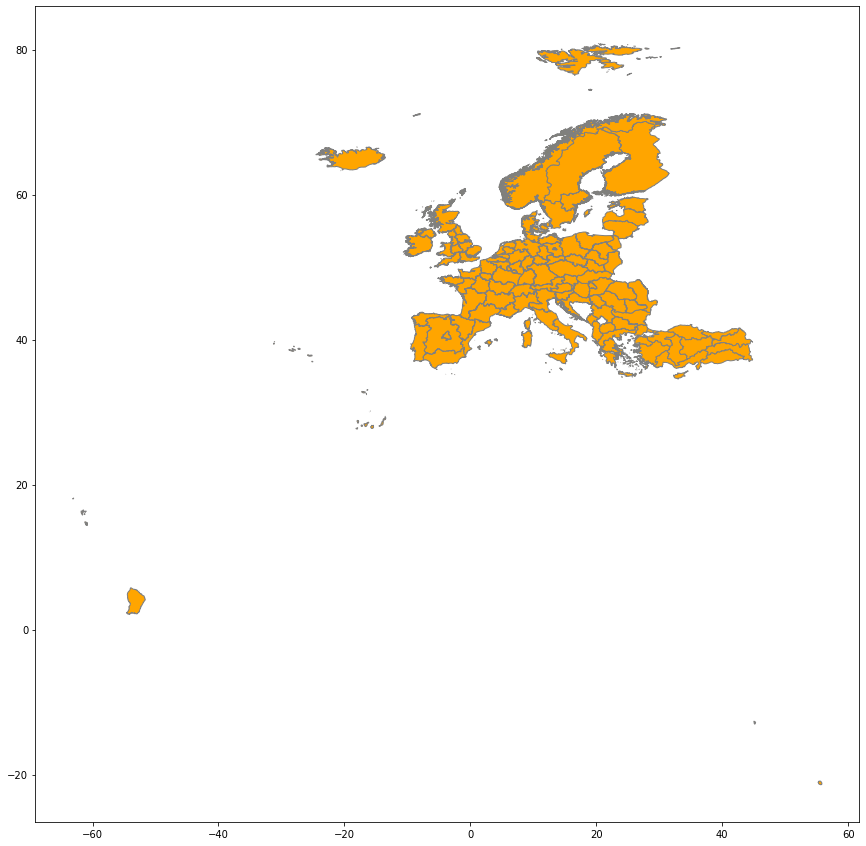

In [17]:
europe_nuts1.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

<AxesSubplot:>

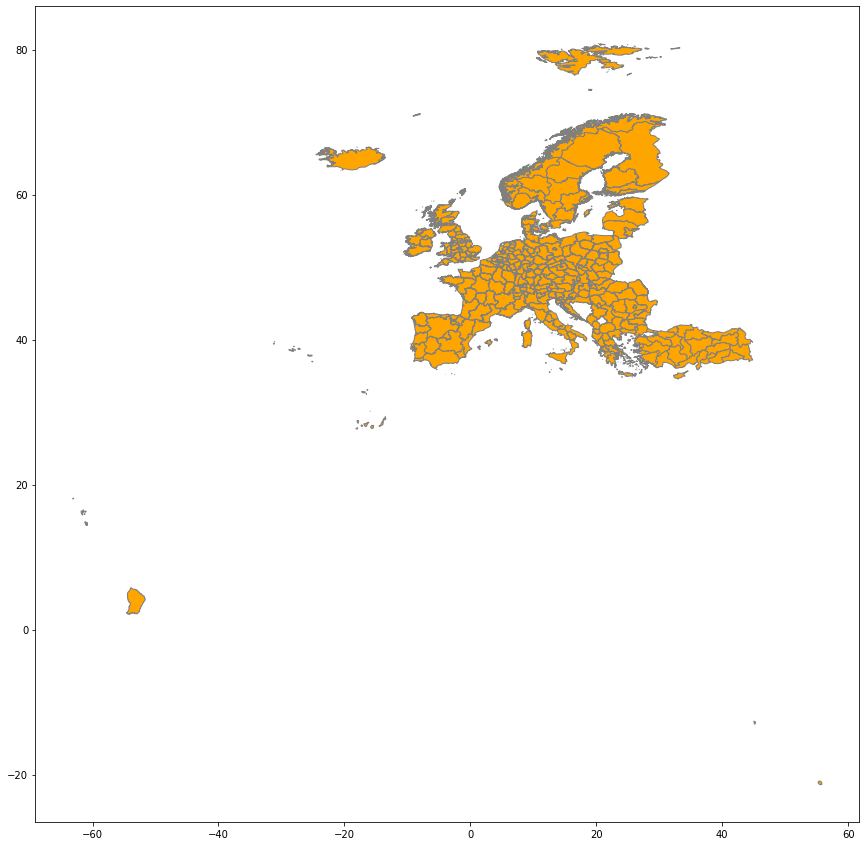

In [18]:
europe_nuts2.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

<AxesSubplot:>

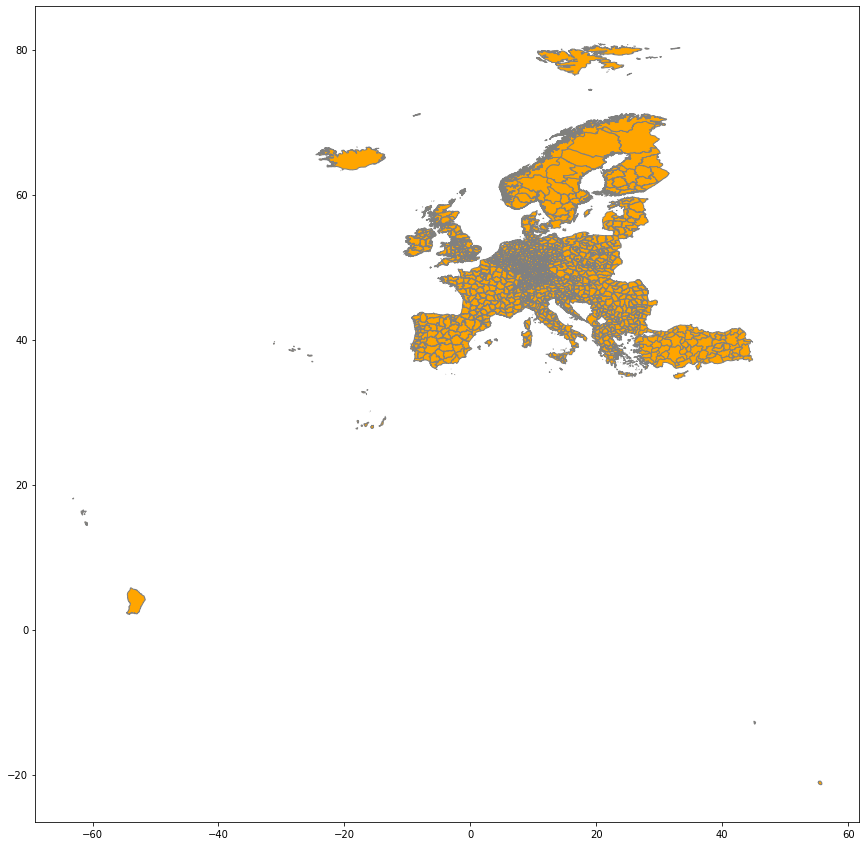

In [19]:
europe_nuts3.plot(facecolor="none", edgecolor='grey', figsize=(20, 15), color='orange')

In [20]:
de0 = europe_nuts0.loc[europe_nuts0['CNTR_CODE'] == 'DE']
de1 = europe_nuts1.loc[europe_nuts1['CNTR_CODE'] == 'DE']
de2 = europe_nuts2.loc[europe_nuts2['CNTR_CODE'] == 'DE']
de3 = europe_nuts3.loc[europe_nuts3['CNTR_CODE'] == 'DE']

In [24]:
de0.reset_index(drop=True, inplace=True)
de1.reset_index(drop=True, inplace=True)
de2.reset_index(drop=True, inplace=True)
de3.reset_index(drop=True, inplace=True)

In [28]:
de3

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry,CNTR_NAME
0,DE21A,DE,Erding,Erding,4.0,3,3,"POLYGON ((12.01712 48.43068, 12.02210 48.42585...",Germany
1,DE94E,DE,"Osnabrück, Landkreis","Osnabrück, Landkreis",4.0,2,3,"POLYGON ((8.01815 52.68391, 8.03442 52.67338, ...",Germany
2,DE94F,DE,Vechta,Vechta,4.0,2,3,"POLYGON ((8.45928 52.80106, 8.45051 52.78637, ...",Germany
3,DE94G,DE,Wesermarsch,Wesermarsch,4.0,2,1,"POLYGON ((8.55490 53.52513, 8.54756 53.52128, ...",Germany
4,DEA59,DE,Olpe,Olpe,2.0,2,3,"POLYGON ((8.23880 51.10434, 8.22833 51.09961, ...",Germany
...,...,...,...,...,...,...,...,...,...
396,DE94H,DE,Wittmund,Wittmund,4.0,3,1,"MULTIPOLYGON (((7.80990 53.70766, 7.83333 53.6...",Germany
397,DEA11,DE,"Düsseldorf, Kreisfreie Stadt","Düsseldorf, Kreisfreie Stadt",4.0,1,3,"POLYGON ((6.85605 51.12619, 6.84978 51.13341, ...",Germany
398,DEG0L,DE,Greiz,Greiz,4.0,2,3,"POLYGON ((12.22417 50.94293, 12.22471 50.93943...",Germany
399,DEG0M,DE,Altenburger Land,Altenburger Land,4.0,2,3,"POLYGON ((12.61735 50.98079, 12.62094 50.97590...",Germany


In [27]:
de0.to_file('Germany/data/DE_NUTS0.shp', encoding = enc)
de1.to_file('Germany/data/DE_NUTS1.shp', encoding = enc)
de2.to_file('Germany/data/DE_NUTS2.shp', encoding = enc)
de3.to_file('Germany/data/DE_NUTS3.shp', encoding = enc)